# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [31]:
import sys
import os

# Pfad anpassen, um utils_notebook und das eval-Modul zu importieren
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Alle modularisierten Funktionen importieren
from utils_notebook.compare import compare_wunden_interactive, compare_categories_detailed_interactive
from utils_notebook.category_compare import compare_categories_interactive
from utils_notebook.wundbild import zeige_wundbild_interactive
from utils_notebook.metrics_explorer import calculate_scores, display_scores_interactive, calculate_summary, display_summary
from utils_notebook.plot_compare import plot_gt_comparison
from utils_notebook.explore import convert_llm_jsons_to_raw_csv
from utils_notebook.clean import normalize_llm_file

# =====================================================================
# EXPERTEN-AUSWAHL (Hier einfach 1 oder 2 eintragen)
# =====================================================================
EXPERT = 2  # 1 = Experte 1, 2 = Experte 2

# Pfade für den gewählten Experten (Ground Truth)
CSV_PATH_RAW = f"../../data/ground_truth/lohmann_rauscher/Experte{EXPERT}_LR_GroundTruth.csv"
CSV_PATH_NORM = f"../../data/ground_truth/lohmann_rauscher/Experte{EXPERT}_LR_GroundTruth_normalised.csv"

# LLM-Output Pfade (Zero-Shot L&R)
JSON_DIR_RAW = "../../data/llm_outputs/zero_shot_lr/zero_shot_lr_raw.csv"
LLM_PATH_NORM = "../../data/llm_outputs/zero_shot_lr/zero_shot_lr_normalised.csv"
RUNS_DIR = "../../runs/gpt-5/zero_shot_lr"

# Zuweisung für Phase 1
CSV_PATH = CSV_PATH_RAW
JSON_DIR = JSON_DIR_RAW

# Automatische Aktualisierung der CSVs aus den JSON-Runs vor dem Laden
if os.path.exists(RUNS_DIR):
    print("Aktualisiere LLM CSV-Tabellen aus den JSON-Runs...")
    convert_llm_jsons_to_raw_csv(RUNS_DIR, JSON_DIR_RAW)
    normalize_llm_file(JSON_DIR_RAW, LLM_PATH_NORM)
# =====================================================================

Aktualisiere LLM CSV-Tabellen aus den JSON-Runs...
Rohe LLM-Tabelle erfolgreich erstellt: ../../data/llm_outputs/zero_shot_lr/zero_shot_lr_raw.csv
Normalisierte LLM-Datei erfolgreich erstellt: ../../data/llm_outputs/zero_shot_lr/zero_shot_lr_normalised.csv


In [32]:
# =====================================================================
# 1. INTERAKTIVER DETAILVERGLEICH PRO WUNDBILD
# =====================================================================
compare_wunden_interactive(CSV_PATH, JSON_DIR)


Erfolgreich 10 Wundbilder zum Vergleich geladen.


interactive(children=(Dropdown(description='Wundbild:', options=('wunde_01', 'wunde_02', 'wunde_03', 'wunde_04…

In [33]:
# =====================================================================
# 2. INTERAKTIVER KATEGORIE-VERGLEICH ALLER WUNDEN
# =====================================================================
compare_categories_interactive(CSV_PATH, JSON_DIR)

Erfolgreich 10 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Lokalisation', 'Wundstadium / -p…

In [34]:
# =====================================================================
# 3. INTERAKTIVE WUNDBILD-ANZEIGE
# =====================================================================
zeige_wundbild_interactive()

interactive(children=(BoundedIntText(value=1, description='Wund-Nummer:', max=50, min=1, style=DescriptionStyl…

In [35]:
# =====================================================================
# 4. METRIKEN-EXPLORER (DETAIL-SCORES PRO WUNDBILD)
# =====================================================================
# raw=True deaktiviert alle on-the-fly Mappings und Bereinigungen
df_scores_raw = calculate_scores(CSV_PATH, JSON_DIR, raw=True)

display_scores_interactive(df_scores_raw)
df_summary_raw = calculate_summary(df_scores_raw)
display_summary(df_summary_raw)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
debridement,checklist,42.0%,10.0%
kompression_produkte,checklist,90.0%,90.0%
sekundaerverband,checklist,0.0%,0.0%
spuelloesung,checklist,60.0%,60.0%
wundrand,checklist,71.3%,30.0%
wundstadium,checklist,63.3%,40.0%
wundumgebung,checklist,68.0%,40.0%
primaerverband,checklist (best path),11.7%,0.0%
lokalisation,decode,0.0%,0.0%
debridement_notwendig,exact,80.0%,80.0%


## Phase 2

In [36]:
# =====================================================================
# WECHSEL ZU DEN NORMALISIERTEN DATENSÄTZEN (Phase 2)
# =====================================================================
# Die Variablen zeigen nun automatisch auf die in Zelle 1 konfigurierten Pfade:
CSV_PATH = CSV_PATH_NORM
JSON_DIR = LLM_PATH_NORM

In [37]:
compare_wunden_interactive(CSV_PATH, JSON_DIR)
compare_categories_interactive(CSV_PATH, JSON_DIR)

Erfolgreich 10 Wundbilder zum Vergleich geladen.


Erfolgreich 10 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Lokalisation', 'Wundstadium / -p…

In [38]:
# =====================================================================
# METRIKEN FÜR DAS NORMALISIERTE GT BERECHNEN UND ANZEIGEN
# =====================================================================
# raw=False aktiviert spelling_mapping und category_decoding
df_scores_norm = calculate_scores(CSV_PATH, JSON_DIR, raw=False)

display_scores_interactive(df_scores_norm)
df_summary_norm = calculate_summary(df_scores_norm)
display_summary(df_summary_norm)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
debridement,checklist,42.0%,10.0%
kompression_produkte,checklist,90.0%,90.0%
sekundaerverband,checklist,0.0%,0.0%
spuelloesung,checklist,60.0%,60.0%
wundrand,checklist,71.3%,30.0%
wundstadium,checklist,63.3%,40.0%
wundumgebung,checklist,68.0%,40.0%
primaerverband,checklist (best path),11.7%,0.0%
lokalisation,decode,33.3%,20.0%
debridement_notwendig,exact,80.0%,80.0%


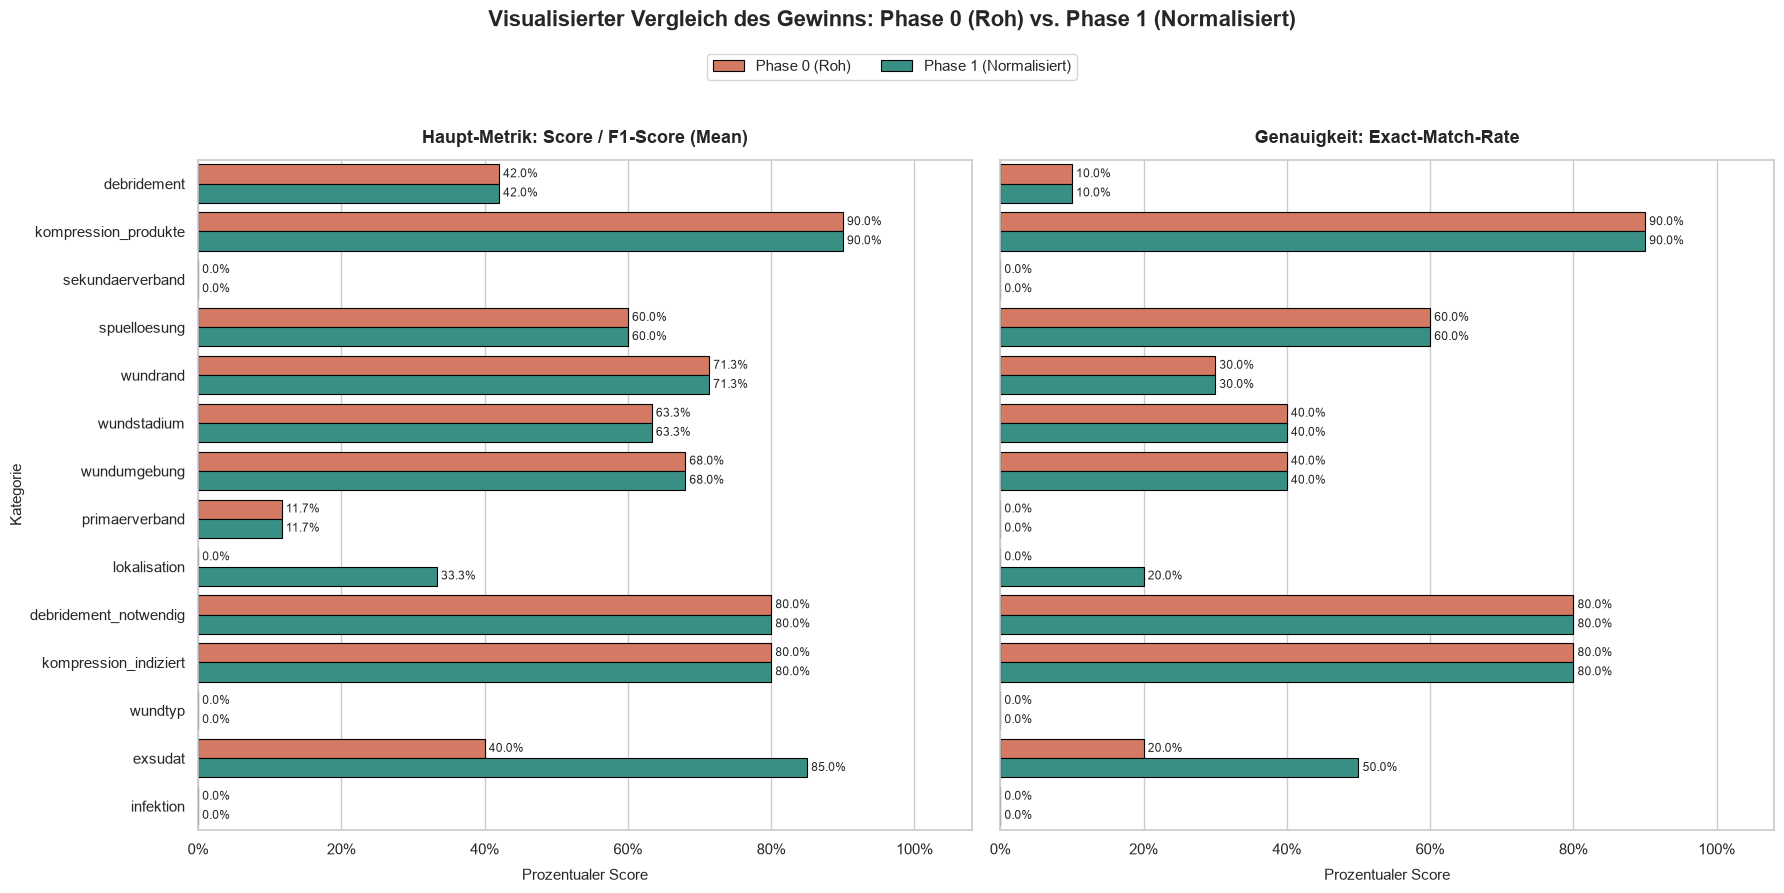

In [39]:
# Vergleicht grafisch Phase 0 und Phase 1 nebeneinander
plot_gt_comparison(df_summary_raw, df_summary_norm)


## Detaillierter Kategorie-Vergleich (Roh vs. Normalisiert)

In diesem Bereich kannst du für eine ausgewählte Kategorie die rohen und die normalisierten Werte von Ground Truth (GT) und LLM-Output gegenüberstellen. Eventuelle Score-Verschlechterungen durch die Normalisierung werden farblich hervorgehoben.

In [40]:
# =====================================================================
# INTERAKTIVER DETAILVERGLEICH PRO KATEGORIE (RAW VS. NORMALISIERT)
# =====================================================================
compare_categories_detailed_interactive(
    raw_csv_gt=CSV_PATH_RAW,
    raw_csv_llm=JSON_DIR_RAW,
    norm_csv_gt=CSV_PATH_NORM,
    norm_csv_llm=LLM_PATH_NORM
)

HTML(value="<h3 style='font-family: Segoe UI, Arial, sans-serif; color: #1d3557; margin-top: 15px;'>GT vs. LLM…

Dropdown(description='Kategorie:', index=13, layout=Layout(width='300px'), options=('alternative_produkt', 'au…

Output()